# WESAD - Data Extraction & Cleaning
**Course:** DATA 230 - Data Intelligence and Visualization  
**Dataset:** WESAD (Wearable Stress and Affect Detection)  

The raw WESAD data comes as `.pkl` files (one per subject). Each file has chest-worn sensor readings sampled at 700 Hz. We need to turn this into a flat CSV we can actually work with for EDA and modeling -- at least 50k rows and 20+ features.

This notebook handles loading the raw data, extracting windowed features, cleaning, and saving the final output.

## Imports

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('done')

done


## Config

Set the path to wherever you downloaded the WESAD folder.

In [2]:
DATA_PATH    = '/Users/rishitha/anaconda_projects/WESAD'
OUTPUT_PATH  = '/Users/rishitha/anaconda_projects/WESAD/output'

os.makedirs(OUTPUT_PATH, exist_ok=True)

SAMPLING_RATE = 700

# 5-sec windows with 0.5-sec overlap -- gives us roughly 6k windows per subject
WINDOW_SIZE   = 5 * 700    # 3500 samples
STEP_SIZE     = 700 // 2   # 350 samples (half-second hop)

# only keeping the 4 labeled conditions, ignoring transition labels (0, 5, 6, 7)
LABEL_MAP    = {1: 'baseline', 2: 'stress', 3: 'amusement', 4: 'meditation'}
VALID_LABELS = [1, 2, 3, 4]

print('data path    :', DATA_PATH)
print('output path  :', OUTPUT_PATH)
print('window       :', WINDOW_SIZE, 'samples =', WINDOW_SIZE / SAMPLING_RATE, 'sec')
print('step         :', STEP_SIZE, 'samples =', STEP_SIZE / SAMPLING_RATE, 'sec')
print('valid labels :', VALID_LABELS)

data path    : /Users/rishitha/anaconda_projects/WESAD
output path  : /Users/rishitha/anaconda_projects/WESAD/output
window       : 3500 samples = 5.0 sec
step         : 350 samples = 0.5 sec
valid labels : [1, 2, 3, 4]


## Loading a single subject to understand the data structure

In [3]:
def load_subject(sid, base_path):
    fpath = os.path.join(base_path, sid, sid + '.pkl')
    if not os.path.exists(fpath):
        raise FileNotFoundError('not found: ' + fpath)
    with open(fpath, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    return data

subj_dirs = sorted([
    d for d in os.listdir(DATA_PATH)
    if d.startswith('S') and os.path.isdir(os.path.join(DATA_PATH, d))
])
print('found subjects:', subj_dirs)
print('count:', len(subj_dirs))

s0 = load_subject(subj_dirs[0], DATA_PATH)
print()
print('structure for', subj_dirs[0])
print('  top keys     :', list(s0.keys()))
print('  signal keys  :', list(s0['signal'].keys()))
print('  chest sensors:', list(s0['signal']['chest'].keys()))
print('  wrist sensors:', list(s0['signal']['wrist'].keys()))
print('  label shape  :', s0['label'].shape)
print('  ECG shape    :', s0['signal']['chest']['ECG'].shape)
print('  EDA shape    :', s0['signal']['chest']['EDA'].shape)

found subjects: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
count: 15

structure for S10
  top keys     : ['signal', 'label', 'subject']
  signal keys  : ['chest', 'wrist']
  chest sensors: ['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp']
  wrist sensors: ['ACC', 'BVP', 'EDA', 'TEMP']
  label shape  : (3847200,)
  ECG shape    : (3847200, 1)
  EDA shape    : (3847200, 1)


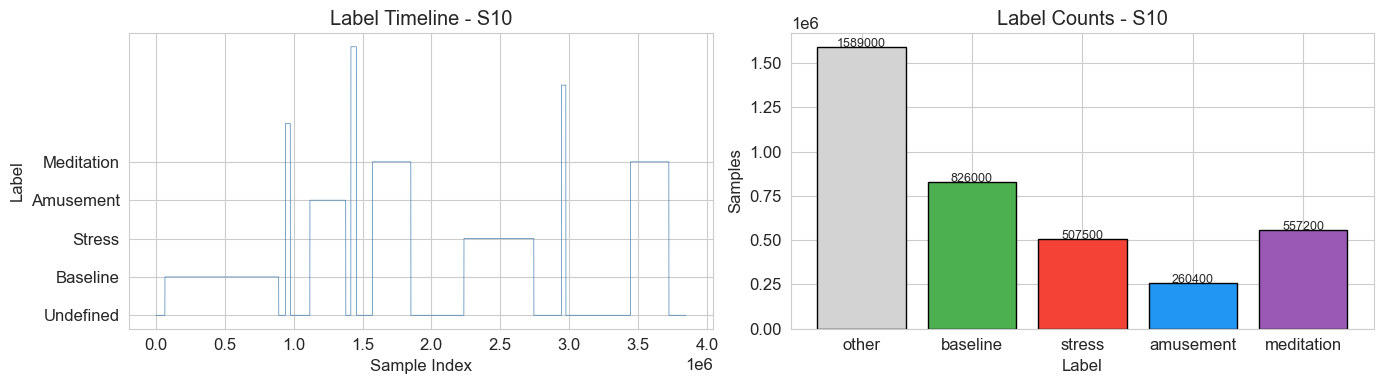

In [4]:
# quick look at the label timeline and distribution for one subject
lbl = s0['label'].flatten()
uvals, ucounts = np.unique(lbl, return_counts=True)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# timeline
ax[0].plot(lbl, linewidth=0.5, color='steelblue')
ax[0].set_title('Label Timeline - ' + subj_dirs[0])
ax[0].set_xlabel('Sample Index')
ax[0].set_ylabel('Label')
ax[0].set_yticks([0, 1, 2, 3, 4])
ax[0].set_yticklabels(['Undefined', 'Baseline', 'Stress', 'Amusement', 'Meditation'])

# bar chart of counts (only labels 0-4)
cmap = {0: '#d3d3d3', 1: '#4CAF50', 2: '#f44336', 3: '#2196F3', 4: '#9b59b6'}
keep = [int(u) in [0, 1, 2, 3, 4] for u in uvals]
uv = uvals[keep]
uc = ucounts[keep]
names = [LABEL_MAP.get(int(u), 'other') for u in uv]
cols  = [cmap.get(int(u), 'gray') for u in uv]
ax[1].bar(names, uc, color=cols, edgecolor='black')
ax[1].set_title('Label Counts - ' + subj_dirs[0])
ax[1].set_xlabel('Label')
ax[1].set_ylabel('Samples')
for i, v in enumerate(uc):
    ax[1].text(i, v + 100, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + '/01_raw_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

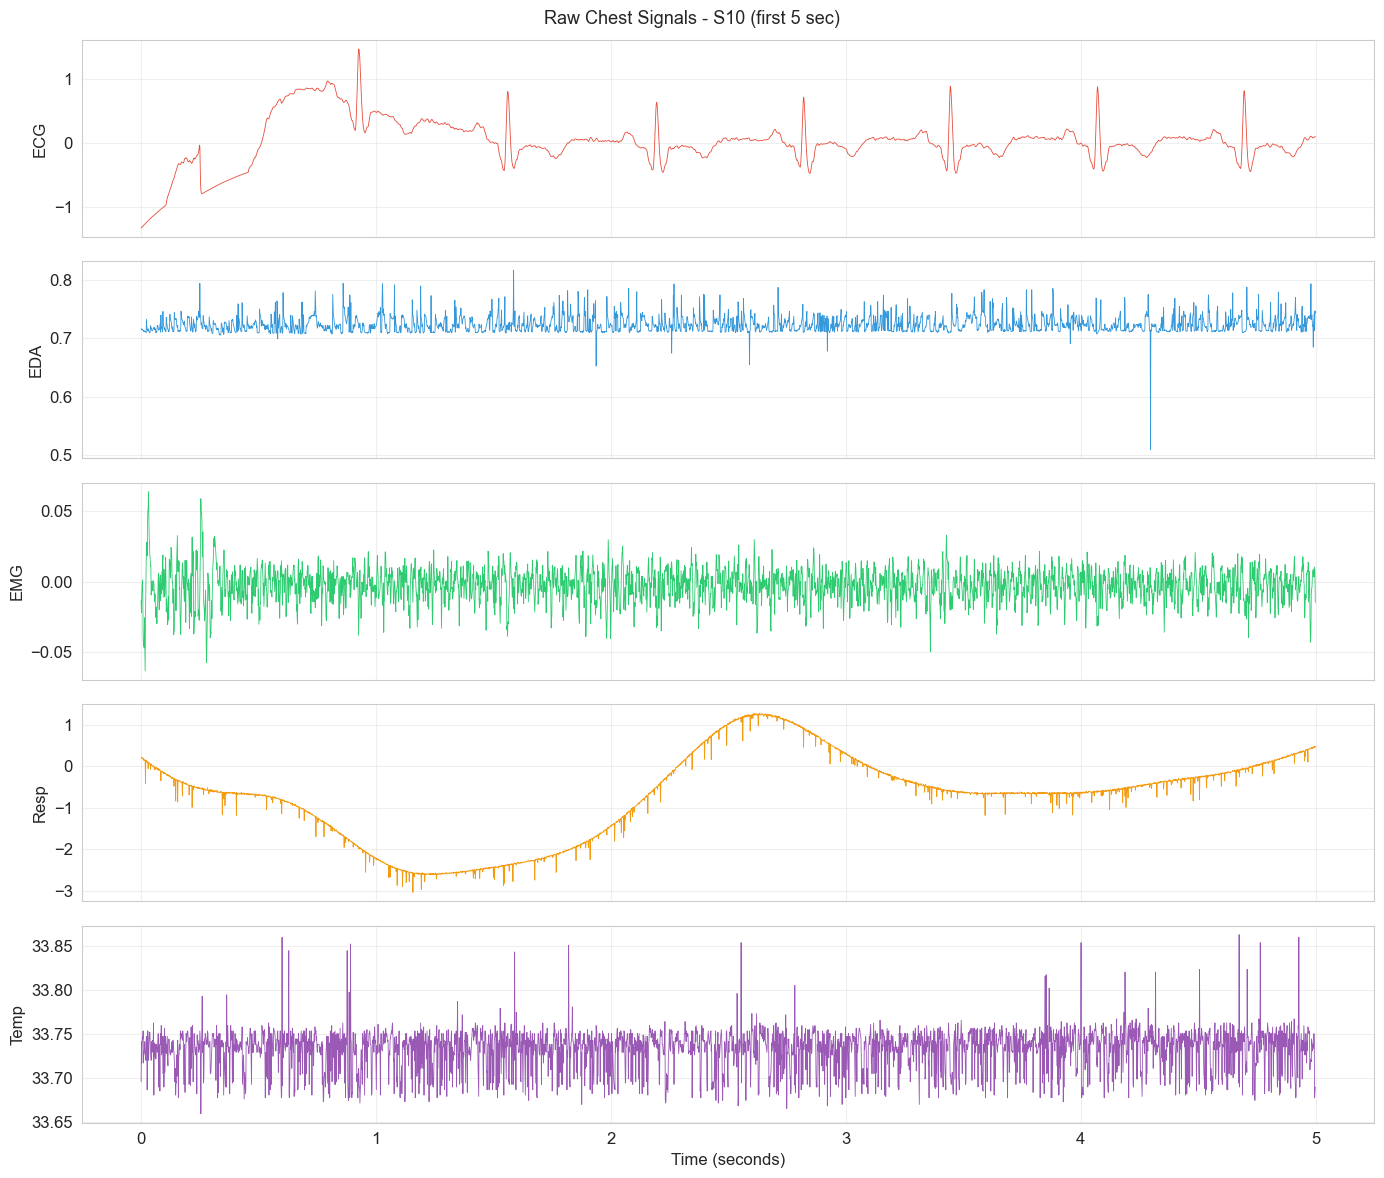

In [5]:
# plotting the first 5 seconds of raw chest signals to see what we're working with
chest = s0['signal']['chest']
n = 5 * SAMPLING_RATE
t = np.arange(n) / SAMPLING_RATE

sig_dict = {
    'ECG'  : chest['ECG'][:n, 0],
    'EDA'  : chest['EDA'][:n, 0],
    'EMG'  : chest['EMG'][:n, 0],
    'Resp' : chest['Resp'][:n, 0],
    'Temp' : chest['Temp'][:n, 0],
}

fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
clrs = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for ax, (name, sig), c in zip(axes, sig_dict.items(), clrs):
    ax.plot(t, sig, color=c, linewidth=0.6)
    ax.set_ylabel(name)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (seconds)')
fig.suptitle('Raw Chest Signals - ' + subj_dirs[0] + ' (first 5 sec)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '/02_raw_signals.png', dpi=150, bbox_inches='tight')
plt.show()

## Sliding Window Feature Extraction

We slide a 5-second window across each subject's signals and compute stats (mean, std, min, max, etc.) per window. This turns the raw time-series into a row-per-window tabular format with 22 columns.

In [6]:
def get_window_features(w):
    # w is shape (WINDOW_SIZE, 8) -- columns: ECG, EDA, EMG, Resp, Temp, ACC_x, ACC_y, ACC_z
    ecg  = w[:, 0]
    eda  = w[:, 1]
    emg  = w[:, 2]
    resp = w[:, 3]
    temp = w[:, 4]
    ax   = w[:, 5]
    ay   = w[:, 6]
    az   = w[:, 7]

    acc_mag = np.sqrt(ax**2 + ay**2 + az**2)

    feats = {
        'ecg_mean'     : np.mean(ecg),
        'ecg_std'      : np.std(ecg),
        'ecg_min'      : np.min(ecg),
        'ecg_max'      : np.max(ecg),

        'eda_mean'     : np.mean(eda),
        'eda_std'      : np.std(eda),
        'eda_min'      : np.min(eda),
        'eda_max'      : np.max(eda),
        'eda_slope'    : np.polyfit(np.arange(len(eda)), eda, 1)[0],

        'emg_mean'     : np.mean(emg),
        'emg_std'      : np.std(emg),
        'emg_rms'      : np.sqrt(np.mean(emg**2)),

        'resp_mean'    : np.mean(resp),
        'resp_std'     : np.std(resp),
        'resp_range'   : np.ptp(resp),

        'temp_mean'    : np.mean(temp),
        'temp_std'     : np.std(temp),
        'temp_slope'   : np.polyfit(np.arange(len(temp)), temp, 1)[0],

        'acc_x_mean'   : np.mean(ax),
        'acc_y_mean'   : np.mean(ay),
        'acc_z_mean'   : np.mean(az),
        'acc_magnitude': np.mean(acc_mag),
    }
    return feats

print('feature extractor ready -- 22 features per window')

feature extractor ready -- 22 features per window


In [7]:
def run_subject(sid, base_path, win_sz, step_sz, keep_labels):
    data   = load_subject(sid, base_path)
    chest  = data['signal']['chest']
    labels = data['label'].flatten()

    # stack all chest signals into one array
    raw = np.column_stack([
        chest['ECG'].flatten(),
        chest['EDA'].flatten(),
        chest['EMG'].flatten(),
        chest['Resp'].flatten(),
        chest['Temp'].flatten(),
        chest['ACC'][:, 0],
        chest['ACC'][:, 1],
        chest['ACC'][:, 2],
    ])

    rows = []
    total_len = len(raw)

    for start in range(0, total_len - win_sz, step_sz):
        end = start + win_sz
        chunk = raw[start:end]
        chunk_labels = labels[start:end]

        vals, cnts = np.unique(chunk_labels, return_counts=True)
        dominant = int(vals[np.argmax(cnts)])

        if dominant not in keep_labels:
            continue

        # skip windows where the dominant label covers less than half
        if np.max(cnts) / win_sz < 0.5:
            continue

        f = get_window_features(chunk)
        f['label']        = dominant
        f['label_name']   = LABEL_MAP[dominant]
        f['subject']      = sid
        f['window_start'] = start
        rows.append(f)

    return rows

print('subject processing function ready')

subject processing function ready


In [8]:
print('running extraction for all subjects...')
print()
all_rows = []
per_subj = []

for sid in tqdm(subj_dirs, desc='subjects'):
    try:
        rows = run_subject(sid, DATA_PATH, WINDOW_SIZE, STEP_SIZE, VALID_LABELS)
        all_rows.extend(rows)
        per_subj.append({'subject': sid, 'windows': len(rows)})
        print(sid, '-', len(rows), 'windows | running total:', len(all_rows))
    except Exception as e:
        print(sid, 'failed:', e)

df_raw = pd.DataFrame(all_rows)
print()
print('total rows   :', len(df_raw))
print('total cols   :', len(df_raw.columns))
print('>= 50k rows? :', len(df_raw) >= 50000)
print('>= 20 feats? :', len(df_raw.columns) >= 20)

running extraction for all subjects...



subjects:   7%|██▎                               | 1/15 [00:04<01:04,  4.64s/it]

S10 - 6146 windows | running total: 6146


subjects:  13%|████▌                             | 2/15 [00:08<00:57,  4.39s/it]

S11 - 6038 windows | running total: 12184


...

subjects:  93%|██████████████████████████████▊  | 14/15 [01:05<00:04,  4.56s/it]

S8 - 6010 windows | running total: 83936


subjects: 100%|█████████████████████████████████| 15/15 [01:09<00:00,  4.61s/it]

S9 - 5980 windows | running total: 89916



total rows   : 89916
total cols   : 26
>= 50k rows? : True
>= 20 feats? : True


In [9]:
print('first 5 rows:')
display(df_raw.head())
print('label distribution:')
display(df_raw['label_name'].value_counts())

first 5 rows:


,ecg_mean,ecg_std,ecg_min,ecg_max,eda_mean,eda_std,eda_min,eda_max,eda_slope,emg_mean,...,temp_std,temp_slope,acc_x_mean,acc_y_mean,acc_z_mean,acc_magnitude,label,label_name,subject,window_start
0,-0.001458,0.136213,-0.566345,0.785843,0.734832,0.012605,0.672913,0.811005,3.076605e-07,-0.002057,...,0.024254,-2.843877e-07,0.886105,0.082543,-0.199110,0.912051,1,baseline,S10,63350
1,-0.002375,0.144511,-0.655106,0.785843,0.735076,0.012607,0.672913,0.811005,-9.673740e-08,-0.002095,...,0.023956,2.380175e-07,0.886205,0.081974,-0.199349,0.912144,1,baseline,S10,63700
2,-0.000726,0.141598,-0.658127,0.785843,0.735211,0.012892,0.651550,0.811005,-7.472433e-08,-0.002105,...,0.023670,1.304081e-07,0.886287,0.081506,-0.199236,0.912151,1,baseline,S10,64050
3,0.002559,0.140687,-0.658127,0.785843,0.735343,0.013077,0.651550,0.796509,5.195749e-08,-0.002205,...,0.023667,4.568078e-08,0.886308,0.081843,-0.199271,0.912206,1,baseline,S10,64400
4,-0.003857,0.147851,-0.663895,0.785843,0.735270,0.012861,0.651550,0.807190,1.729311e-07,-0.002193,...,0.023769,6.305371e-07,0.885992,0.082364,-0.200320,0.912170,1,baseline,S10,64750


label distribution:


label_name
baseline      35222
meditation    23612
stress        19932
amusement     11150
Name: count, dtype: int64

## Data Cleaning

### Missing values

no missing values found


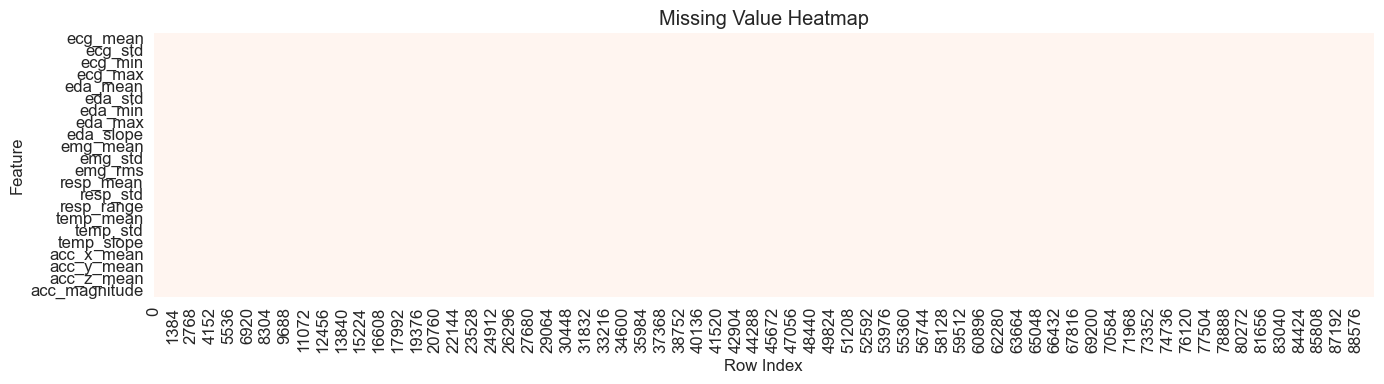

saved: 03_missing_values_heatmap.png


In [10]:
missing     = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df  = missing_df[missing_df['Missing Count'] > 0]

if len(missing_df) == 0:
    print('no missing values found')
else:
    print('missing values in', len(missing_df), 'columns:')
    display(missing_df)

fig, ax = plt.subplots(figsize=(14, 4))
feature_cols   = [c for c in df_raw.columns if c not in ['label','label_name','subject','window_start']]
missing_matrix = df_raw[feature_cols].isnull()
sns.heatmap(missing_matrix.T, cbar=False, cmap='Reds', ax=ax, yticklabels=True)
ax.set_title('Missing Value Heatmap')
ax.set_xlabel('Row Index')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '/03_missing_values_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved: 03_missing_values_heatmap.png')

### Outlier removal (z-score method)

shape before outlier removal: (89916, 26)
outlier rows detected (z > 4.0 ): 8474 (9.42%)
shape after outlier removal: (81442, 26)


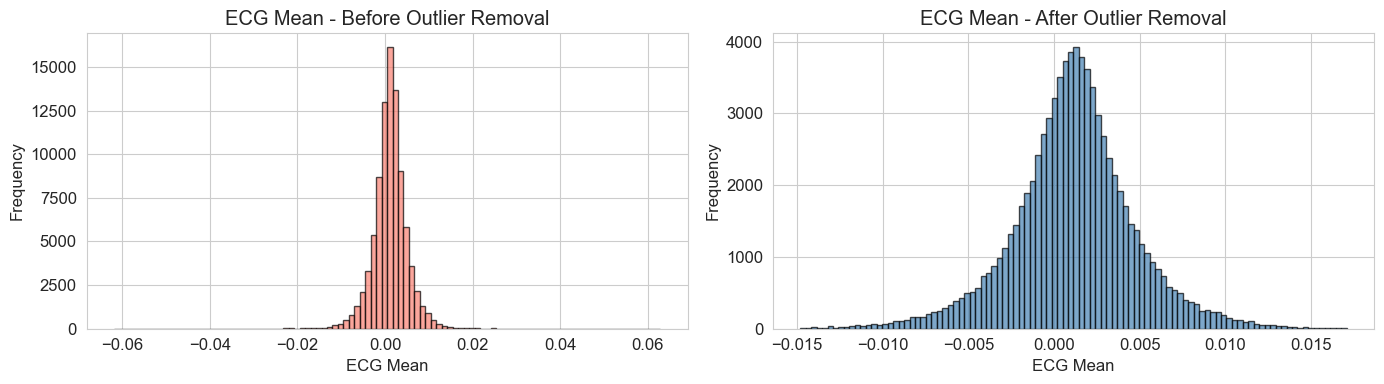

saved: 04_outlier_removal.png


In [11]:
df_clean     = df_raw.copy()
feature_cols = [c for c in df_clean.columns
                if c not in ['label', 'label_name', 'subject', 'window_start']]

print('shape before outlier removal:', df_clean.shape)

Z_THRESHOLD  = 4.0
z_scores     = np.abs(stats.zscore(df_clean[feature_cols]))
outlier_mask = (z_scores > Z_THRESHOLD).any(axis=1)
n_outliers   = outlier_mask.sum()

print('outlier rows detected (z >', Z_THRESHOLD, '):', n_outliers,
      '(' + str(round(n_outliers/len(df_clean)*100, 2)) + '%)')

df_clean = df_clean[~outlier_mask].reset_index(drop=True)
print('shape after outlier removal:', df_clean.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_raw['ecg_mean'], bins=100, color='salmon', edgecolor='black', alpha=0.7)
axes[0].set_title('ECG Mean - Before Outlier Removal')
axes[0].set_xlabel('ECG Mean')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_clean['ecg_mean'], bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title('ECG Mean - After Outlier Removal')
axes[1].set_xlabel('ECG Mean')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + '/04_outlier_removal.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved: 04_outlier_removal.png')

### Class distribution after cleaning

class distribution after cleaning:
  baseline : 31384 (38.5%)
  meditation : 22618 (27.8%)
  stress : 16505 (20.3%)
  amusement : 10935 (13.4%)


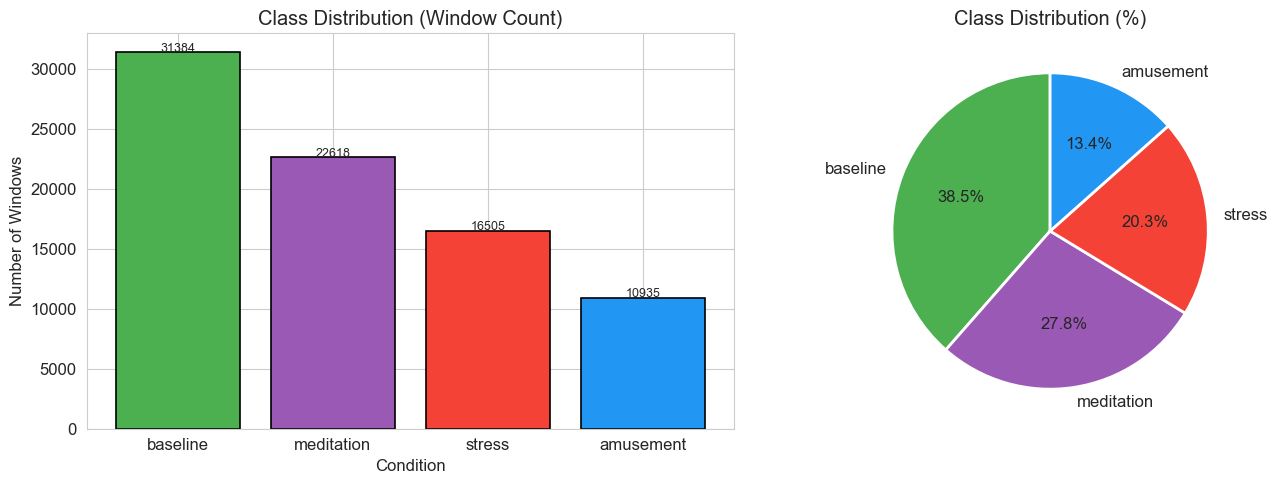

saved: 05_class_distribution.png


In [12]:
class_counts = df_clean['label_name'].value_counts()
class_pct    = (class_counts / len(df_clean) * 100).round(1)

print('class distribution after cleaning:')
for cls, cnt in class_counts.items():
    print(' ', cls, ':', cnt, '(' + str(class_pct[cls]) + '%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors     = {'baseline': '#4CAF50', 'stress': '#f44336',
              'amusement': '#2196F3', 'meditation': '#9b59b6'}
bar_colors = [colors.get(c, 'gray') for c in class_counts.index]

bars = axes[0].bar(class_counts.index, class_counts.values,
                   color=bar_colors, edgecolor='black', linewidth=1.2)
axes[0].set_title('Class Distribution (Window Count)')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Number of Windows')
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50, str(val), ha='center', fontsize=9)

axes[1].pie(class_counts.values, labels=class_counts.index,
            colors=bar_colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + '/05_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved: 05_class_distribution.png')

### Subject-level distribution

windows per subject per label:


label_name,amusement,baseline,meditation,stress
subject,,,,
S10,744,2360,1586,1440
S11,735,2350,894,1360
S13,738,2341,1572,1057
S14,683,2326,1573,1244
S15,739,2247,1572,1279
S16,729,2357,1568,1321
S17,717,2278,1288,1446
S2,724,361,1536,1192
S3,736,2103,1547,883


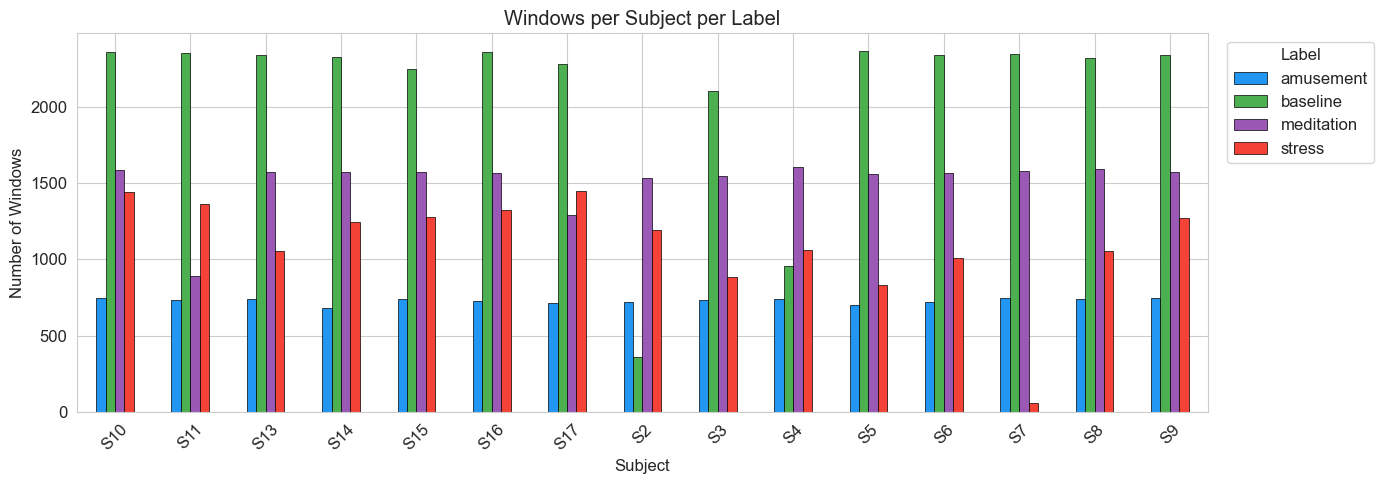

saved: 06_windows_per_subject.png


In [13]:
subject_label = df_clean.groupby(['subject', 'label_name']).size().unstack(fill_value=0)
print('windows per subject per label:')
display(subject_label)

fig, ax = plt.subplots(figsize=(14, 5))
subject_label.plot(kind='bar', ax=ax,
                   color=[colors.get(c, 'gray') for c in subject_label.columns],
                   edgecolor='black', linewidth=0.5)
ax.set_title('Windows per Subject per Label')
ax.set_xlabel('Subject')
ax.set_ylabel('Number of Windows')
ax.legend(title='Label', bbox_to_anchor=(1.01, 1))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '/06_windows_per_subject.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved: 06_windows_per_subject.png')

## Normalization and Encoding

In [14]:
df_final = df_clean.copy()

# binary label: 1 = stress, 0 = not stressed
df_final['label_binary']      = (df_final['label'] == 2).astype(int)
df_final['label_binary_name'] = df_final['label_binary'].map({1: 'stress', 0: 'non-stress'})

# encode subject as integer
le = LabelEncoder()
df_final['subject_id'] = le.fit_transform(df_final['subject'])

# standard scaling on feature columns
scaler    = StandardScaler()
df_scaled = df_final.copy()
df_scaled[feature_cols] = scaler.fit_transform(df_final[feature_cols])

print('normalization done')
print('features scaled    :', len(feature_cols))
print('binary label       : 1=stress, 0=non-stress')
print('multi-class labels : 1=baseline, 2=stress, 3=amusement, 4=meditation')
print()
print('columns:', list(df_scaled.columns))

normalization done
features scaled    : 22
binary label       : 1=stress, 0=non-stress
multi-class labels : 1=baseline, 2=stress, 3=amusement, 4=meditation

columns: ['ecg_mean', 'ecg_std', 'ecg_min', 'ecg_max', 'eda_mean', 'eda_std', 'eda_min', 'eda_max', 'eda_slope', 'emg_mean', 'emg_std', 'emg_rms', 'resp_mean', 'resp_std', 'resp_range', 'temp_mean', 'temp_std', 'temp_slope', 'acc_x_mean', 'acc_y_mean', 'acc_z_mean', 'acc_magnitude', 'label', 'label_name', 'subject', 'window_start', 'label_binary', 'label_binary_name', 'subject_id']


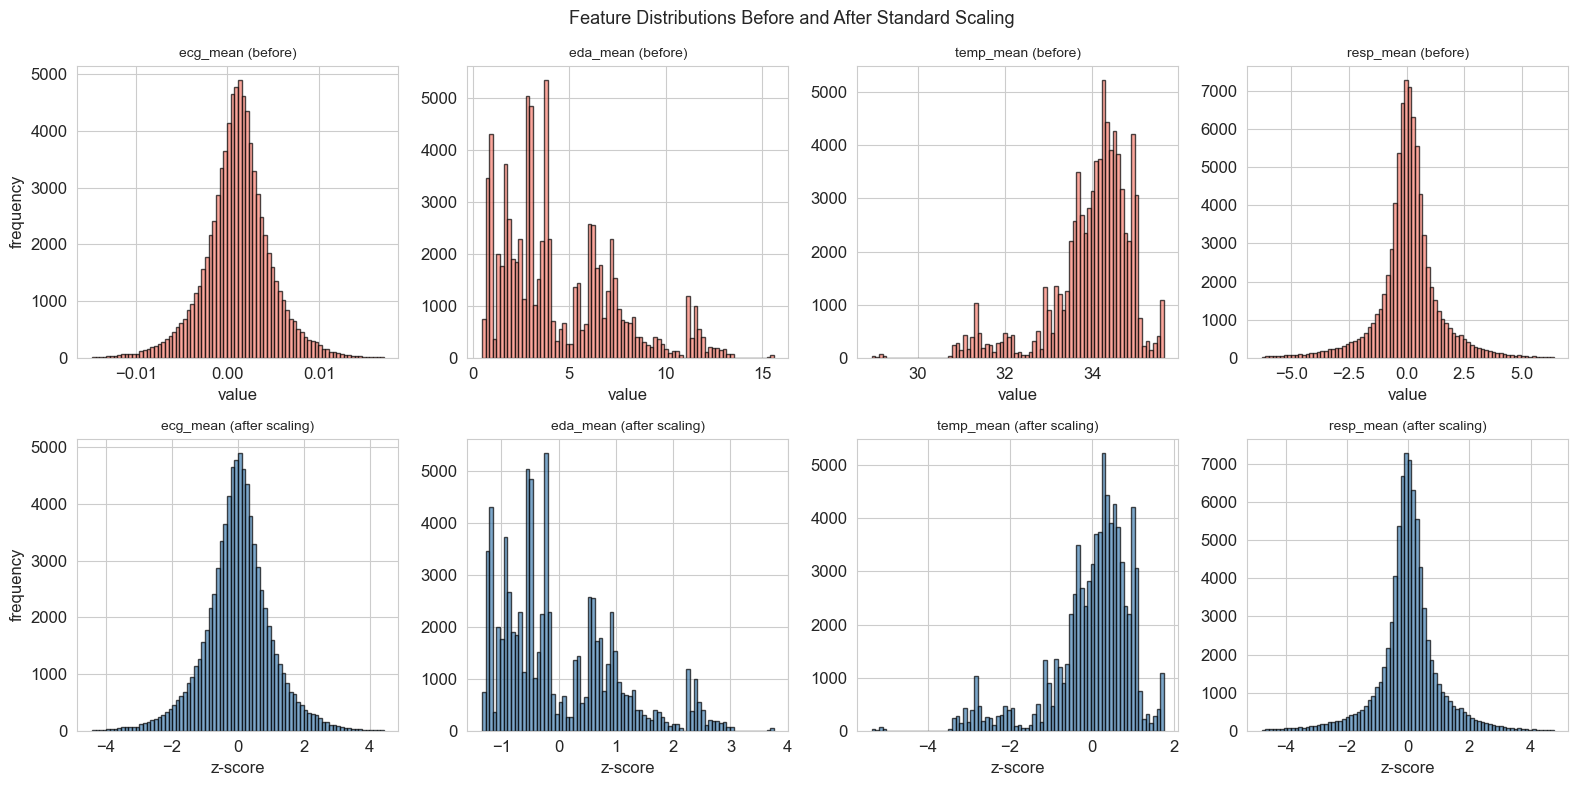

saved: 07_normalization.png


In [15]:
features_to_show = ['ecg_mean', 'eda_mean', 'temp_mean', 'resp_mean']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, feat in enumerate(features_to_show):
    axes[0, i].hist(df_final[feat], bins=80, color='salmon', edgecolor='black', alpha=0.7)
    axes[0, i].set_title(feat + ' (before)', fontsize=10)
    axes[0, i].set_xlabel('value')
    if i == 0: axes[0, i].set_ylabel('frequency')

    axes[1, i].hist(df_scaled[feat], bins=80, color='steelblue', edgecolor='black', alpha=0.7)
    axes[1, i].set_title(feat + ' (after scaling)', fontsize=10)
    axes[1, i].set_xlabel('z-score')
    if i == 0: axes[1, i].set_ylabel('frequency')

fig.suptitle('Feature Distributions Before and After Standard Scaling', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '/07_normalization.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved: 07_normalization.png')

## Save Final Datasets

In [16]:
# wesad_features_raw.csv    - actual values, use for EDA visualizations
# wesad_features_scaled.csv - normalized, use for ML models
# wesad_ml_ready.csv        - features and labels only

path_raw = OUTPUT_PATH + '/wesad_features_raw.csv'
df_final.to_csv(path_raw, index=False)
print('saved wesad_features_raw.csv    -', df_final.shape)

path_scaled = OUTPUT_PATH + '/wesad_features_scaled.csv'
df_scaled.to_csv(path_scaled, index=False)
print('saved wesad_features_scaled.csv -', df_scaled.shape)

ml_cols = feature_cols + ['label', 'label_name', 'label_binary', 'label_binary_name', 'subject']
path_ml = OUTPUT_PATH + '/wesad_ml_ready.csv'
df_scaled[ml_cols].to_csv(path_ml, index=False)
print('saved wesad_ml_ready.csv        -', df_scaled[ml_cols].shape)

saved wesad_features_raw.csv    - (81442, 29)
saved wesad_features_scaled.csv - (81442, 29)
saved wesad_ml_ready.csv        - (81442, 27)


## Summary

In [17]:
print('subjects processed :', len(subj_dirs))
print('sampling rate      :', SAMPLING_RATE, 'Hz')
print('window size        :', WINDOW_SIZE, 'samples =', WINDOW_SIZE // SAMPLING_RATE, 'seconds')
print('step size          :', STEP_SIZE, 'samples =', round(STEP_SIZE / SAMPLING_RATE, 2), 'seconds')
print()
print('rows before cleaning :', len(df_raw))
print('rows after cleaning  :', len(df_clean))
print('rows removed         :', len(df_raw) - len(df_clean))
print()
print('features             :', len(feature_cols))
print('feature list         :', feature_cols)
print()
for cls, cnt in df_clean['label_name'].value_counts().items():
    pct = cnt / len(df_clean) * 100
    print(cls, ':', cnt, '(' + str(round(pct, 1)) + '%)')
print()
print('50k rows requirement :', len(df_clean) >= 50000, '(', len(df_clean), 'rows )')
print('20 feat requirement  :', len(feature_cols) >= 20, '(', len(feature_cols), 'features )')

subjects processed : 15
sampling rate      : 700 Hz
window size        : 3500 samples = 5 seconds
step size          : 350 samples = 0.5 seconds

rows before cleaning : 89916
rows after cleaning  : 81442
rows removed         : 8474

features             : 22
feature list         : ['ecg_mean', 'ecg_std', 'ecg_min', 'ecg_max', 'eda_mean', 'eda_std', 'eda_min', 'eda_max', 'eda_slope', 'emg_mean', 'emg_std', 'emg_rms', 'resp_mean', 'resp_std', 'resp_range', 'temp_mean', 'temp_std', 'temp_slope', 'acc_x_mean', 'acc_y_mean', 'acc_z_mean', 'acc_magnitude']

baseline : 31384 (38.5%)
meditation : 22618 (27.8%)
stress : 16505 (20.3%)
amusement : 10935 (13.4%)

50k rows requirement : True ( 81442 rows )
20 feat requirement  : True ( 22 features )


In [18]:
print('descriptive statistics:')
display(df_final[feature_cols].describe().round(4))

descriptive statistics:


,ecg_mean,ecg_std,ecg_min,ecg_max,eda_mean,eda_std,eda_min,eda_max,eda_slope,emg_mean,...,resp_mean,resp_std,resp_range,temp_mean,temp_std,temp_slope,acc_x_mean,acc_y_mean,acc_z_mean,acc_magnitude
count,81442.0000,81442.0000,81442.0000,81442.0000,81442.0000,81442.0000,81442.0000,81442.0000,81442.0000,81442.0000,...,81442.0000,81442.0000,81442.0000,81442.0000,81442.0000,81442.0000,81442.0000,81442.0000,81442.0000,81442.0000
mean,0.0011,0.2577,-0.5239,1.4094,4.4400,0.0143,4.3527,4.5335,-0.0000,-0.0031,...,0.0634,2.7239,9.2276,33.9943,0.0254,0.0000,0.7790,-0.0240,-0.3829,0.9329
std,0.0036,0.0631,0.1916,0.2125,2.9700,0.0121,2.9715,2.9677,0.0000,0.0006,...,1.3284,1.5451,4.8943,0.9388,0.0076,0.0000,0.1437,0.0849,0.2961,0.0173
min,-0.0148,0.0938,-1.3545,0.5935,0.4687,0.0043,0.2632,0.5634,-0.0001,-0.0048,...,-6.2765,0.0957,0.8392,28.9517,0.0115,-0.0002,0.2596,-0.4225,-0.9441,0.8993
25%,-0.0008,0.2273,-0.6777,1.4670,2.0911,0.0091,2.0073,2.1881,-0.0000,-0.0035,...,-0.4337,1.7268,6.0577,33.6542,0.0217,-0.0000,0.7026,-0.0530,-0.6124,0.9200
50%,0.0012,0.2618,-0.4773,1.4931,3.6566,0.0111,3.5381,3.7468,-0.0000,-0.0030,...,0.0666,2.3626,8.0566,34.1978,0.0258,0.0000,0.8378,-0.0149,-0.3887,0.9286
75%,0.0031,0.2928,-0.3771,1.4992,6.3889,0.0138,6.2947,6.4987,0.0000,-0.0026,...,0.5977,3.3219,11.0611,34.5866,0.0286,0.0000,0.8915,0.0212,-0.1941,0.9422
max,0.0171,0.4878,-0.1615,1.5000,15.5978,0.1313,15.5170,15.7272,0.0001,0.0006,...,6.3815,10.5907,34.2010,35.6403,0.3074,0.0003,0.9178,0.2774,0.6897,0.9835
